In [1]:
from UHI_statistics import *
from Montreal_UHI_toolbox import *
import plotly.graph_objects as go

/runoff/gulley/.miniconda3/lib/python3.12/site-packages/gribapi/__init__.py:23: UserWarning: ecCodes 2.39.0 or higher is recommended. You are running version 2.14.1
  warnings.warn(


In [2]:
obs

<xarray.Dataset> Size: 2MB
Dimensions:                        (station: 12, time: 8401)
Coordinates:
  * station                        (station) object 96B '7014160' ... '7033650'
  * time                           (time) datetime64[ns] 67kB 2000-01-01 ... ...
    stnid                          (station) object 96B '7014160' ... '7033650'
    station_name                   (station) object 96B "L'ASSOMPTION" ... 'L...
    lon                            (station) float64 96B -73.43 ... -74.33
    lat                            (station) float64 96B 45.82 45.5 ... 45.65
    urban_fraction_blurred_std1p5  (station) float64 96B 0.14 ... 0.1385
    lake_fraction_blurred_std1p5   (station) float64 96B 0.001426 ... 0.002588
Data variables:
    elev                           (station) float64 96B 21.0 91.0 ... 49.0 91.0
    prov                           (station) object 96B 'QUE' 'QUE' ... 'QUE'
    joined                         (station) object 96B 'y' 'n' 'n' ... 'y' 'n'
    rcs                            (station) object 96B 'n' 'n' 'n' ... 'y' 'n'
    tas                            (station, time) float64 806kB -8.4 ... 3.8
    tasmax                         (station, time) float64 806kB -2.0 ... 5.5
    tasmin                         (station, time) float64 806kB -14.7 ... 2.1
Attributes: (12/14)
    title:                Third Generation of Homogenized Daily Temperature f...
    history:              2024-06-11 : Convert from original format to NetCDF
    type:                 station_obs
    institute:            Environment and Climate Change Canada
    institute_id:         ECCC
    dataset_id:           AHCCD_gen3_day_temperature
    ...                   ...
    abstract:             Adjusted and Homogenized Canadian Climate Data (AHC...
    dataset_description:  https://crd-data-donnees-rdc.ec.gc.ca/CDAS/products...
    license_type:         permissive
    license:              https:/open.canada.ca/en/open-government-licence-ca...
    DODS.strlen:          1
    DODS.dimName:         string1

In [2]:
# Get the mean and std for UHI during HWD (order: Observation, TEB+CLASS, CLASS)
n_hwd = 11 # contiguous heatwave events

mean_hwd = []
std_hwd = []

# UHI for HWD is different than the weighted UHI for HWD - use the former
for field,model in zip(['tasmin_S','tasmin_T', 'tasmin_C'],['Observation','TEB+CLASS', 'CLASS']):
    # Load tasmin for each model 
    rural_hwd = temps_daily[field].sel(time=registered_heat_days).sel(station=obs_rural.station)
    urban_hwd = temps_daily[field].sel(time=registered_heat_days).sel(station=obs_urban.station)
    UHI_hwd = urban_hwd.mean(dim='station') - rural_hwd.mean(dim='station')
    UHI_hwd_mean = UHI_hwd.mean(dim='time')
    UHI_hwd_std = UHI_hwd.std(dim='time')

    mean_hwd.append(float(UHI_hwd_mean.values))
    std_hwd.append(float(UHI_hwd_std.values))

In [3]:
# Get the mean and std for UHI during all JJA (order: Observation, TEB+CLASS, CLASS)
n_jja = 23 # sampled summers

mean_jja = []
std_jja = []

f = 'tasmin'
s = 'JJA'
for m in ['S','T', 'C']:
    mean_jja.append(float(UHI_Y[f][m][s].mean(dim='year')))
    std_jja.append(float(UHI_Y[f][m][s].std(dim='year')))

In [4]:
errors = []
anomaly = [0,0,0] # Observation, TEB+CLASS, CLASS

for i in range(len(std_jja)):
    # Calculate the anomaly for Observation, TEB+CLASS, CLASS
    anomaly[i] = mean_hwd[i] - mean_jja[i]

    # Perform Welch's t-test given two unequal sample sizes
    result = stats.ttest_ind_from_stats(
        mean1=mean_hwd[i], std1=std_hwd[i], nobs1=n_hwd,
        mean2=mean_jja[i], std2=std_jja[i], nobs2=n_jja,
        equal_var=False
    )

    # 95% CI for the difference in mean
    se = np.sqrt((std_hwd[i]**2 / n_hwd) + (std_jja[i]**2 / n_jja)) # Standard error
    df = se**4 / ((std_hwd[i]**2 / n_hwd)**2 / (n_hwd - 1) + (std_jja[i]**2 / n_jja)**2 / (n_jja - 1)) # Welch-Satterthwaite degrees of freedom

    t_crit = stats.t.ppf(1-alpha/2, df)
    errors.append(float(t_crit * se)) # mean +- error gives CI 
    print(result, ' anomaly:', anomaly[i], '+-', errors[i])

Ttest_indResult(statistic=-0.6102173624281043, pvalue=0.5548552909299287)  anomaly: -0.2664463231624241 +- 0.9682234216227079
Ttest_indResult(statistic=1.2852523983681343, pvalue=0.22694364741112463)  anomaly: 0.46320671858620077 +- 0.8002195154923031
Ttest_indResult(statistic=0.6656995998785513, pvalue=0.5203215353595121)  anomaly: 0.18277184834127194 +- 0.6098405454717054


In [5]:
labels  = ['Observation', 'TEB+CLASS', 'CLASS']
colors  = ['black', 'red', 'blue']

fig = go.Figure()

for label, anom, err, color in zip(labels, anomaly, errors, colors):
    fig.add_trace(go.Scatter(
        x=np.round([anom],2),
        y=[label],
        marker=dict(symbol='square', size=10, color=color),
        error_x=dict(type='data', array=np.round([err],2), visible=True, color=color),
        name=label,
        showlegend=False,
        textfont=dict(color=color, size=11),
    ))

fig.update_layout(
    title=f'Anomaly of HWD Minimum Daily Temperature UHI With Respect to Summer Average',
    xaxis_title='<sup>HWD</sup><span style="text-decoration: overline;">UHI</span><sub>min</sub> - <sup>JJA</sup><span style="text-decoration: overline;">UHI</span><sub>min</sub> (°C)',
    xaxis=dict(range=[-1.5, 1.5]),
    yaxis=dict(autorange='reversed'),
    font=FONT
)

fig.show()
# fig.write_html('/runoff/gulley/UHI_plots/hwd_anomalies/tasmin_UHI_JJA_anom.html')

In [6]:
# Where are the latent and sensible heat fluxes during heat waves anomalous during extreme heat periods?

# Latent heat flux 'hfls'
latent_C, latent_T = get_outputs('hfls')

# Sensible heat flux
sensible_C, sensible_T = get_outputs('hfss')

# Minimum Daily Temperatures
tasmin_C, tasmin_T = get_outputs('tasmin')

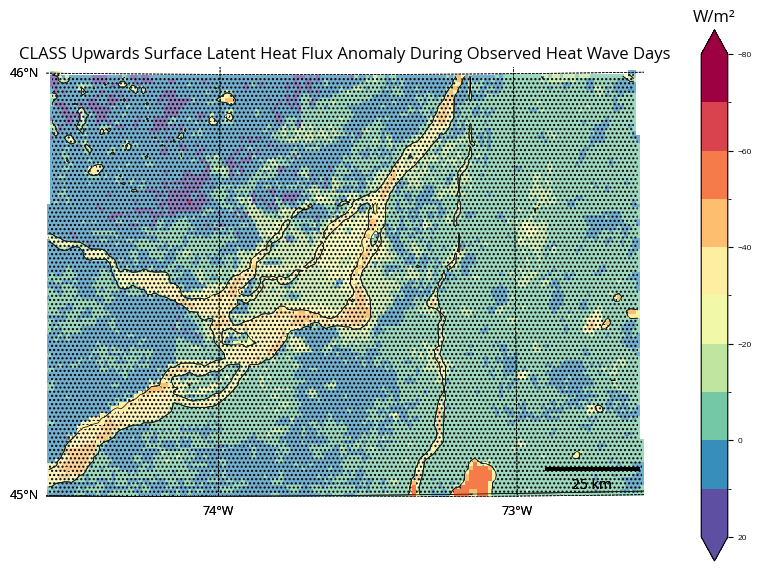

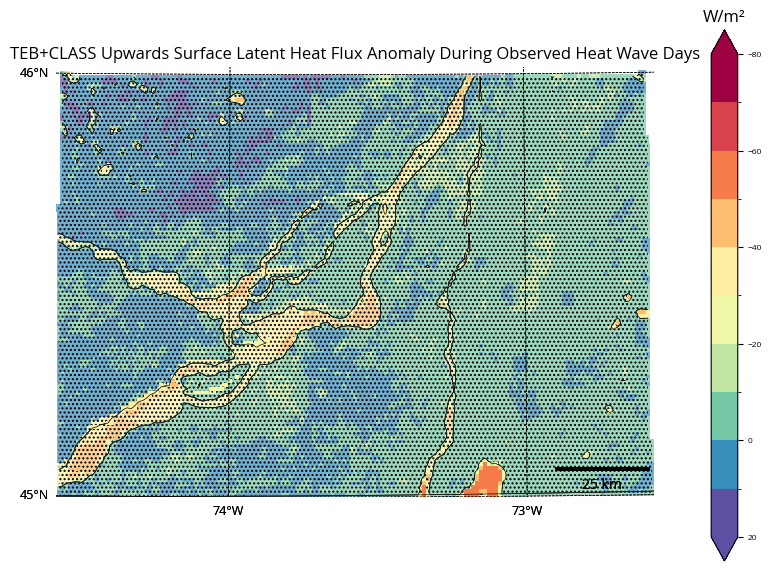

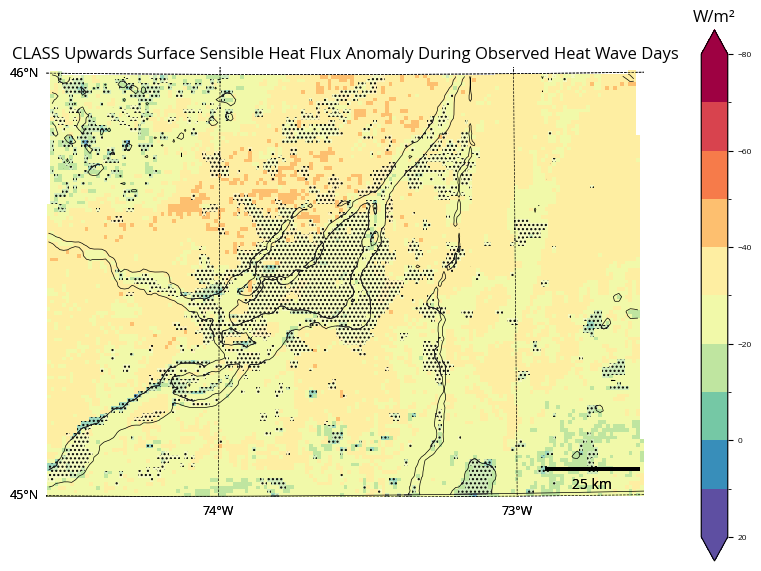

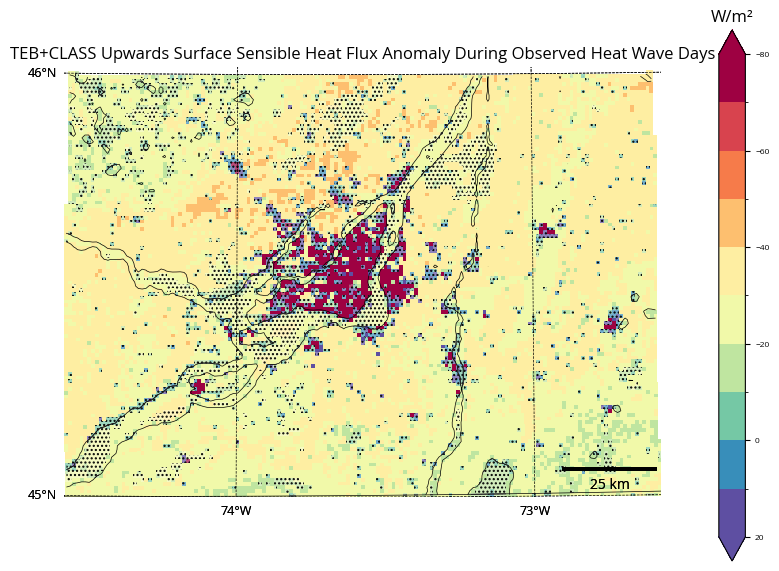

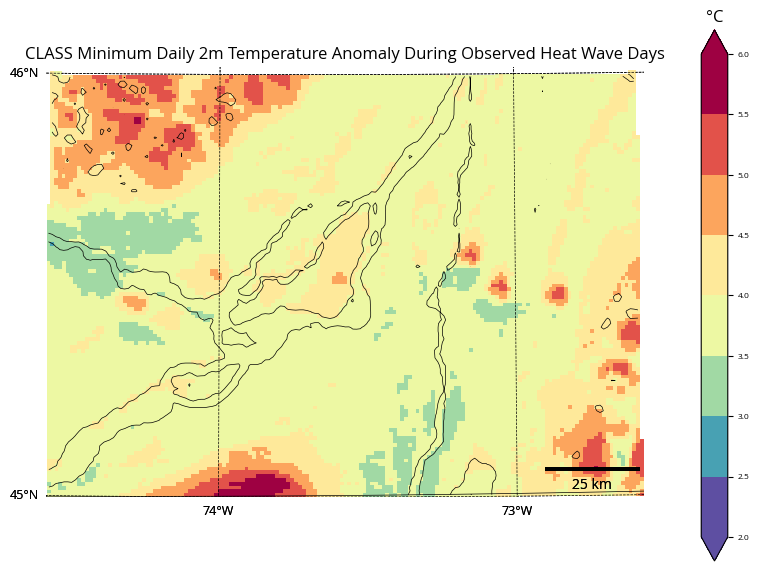

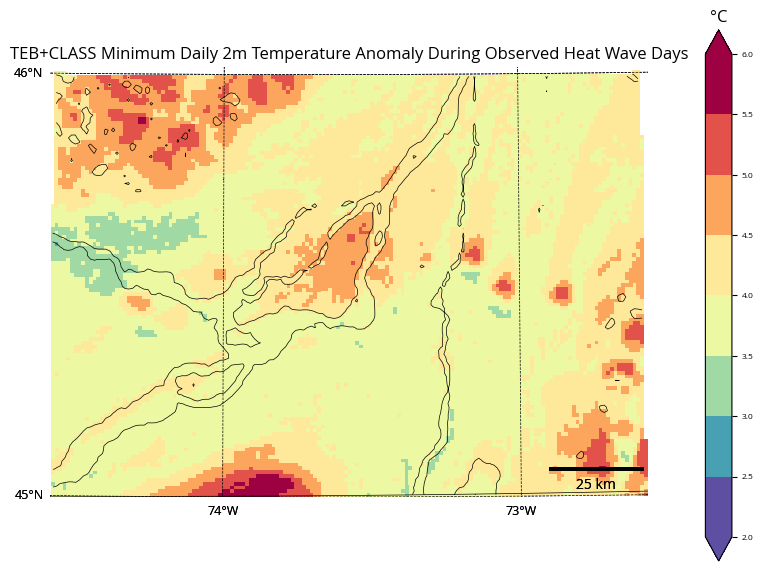

In [13]:
alpha = 0.05 # 95% CI

for field, name, model, vmin, vmax, units, filename, num_levels in zip([latent_C, latent_T, sensible_C, sensible_T, tasmin_C, tasmin_T],
                                ['Upwards Surface Latent Heat Flux','Upwards Surface Latent Heat Flux', 'Upwards Surface Sensible Heat Flux', 'Upwards Surface Sensible Heat Flux', 'Minimum Daily 2m Temperature', 'Minimum Daily 2m Temperature'],
                                ['CLASS', 'TEB+CLASS', 'CLASS', 'TEB+CLASS','CLASS', 'TEB+CLASS'],
                                [ 20, 20, 20, 20, 2, 2], 
                                [-80,-80,-80,-80, 6, 6],
                                ['W/m²','W/m²','W/m²','W/m²','°C','°C'],
                                ['latent_C', 'latent_T', 'sensible_C', 'sensible_T', 'tasmin_C', 'tasmin_T'],
                                [10,10,10,10,8,8]):

    colorscale = 'Spectral_r'
    field_hwd = field.sel(time=registered_heat_days)
    JJA = field.groupby(['time.season','time.year']).mean(dim='time').sel(season='JJA')

    mean_hwd = field_hwd.mean(dim='time')
    std_hwd  = field_hwd.std(dim='time',ddof=1)

    mean_jja = JJA.mean(dim='year')
    std_jja  = JJA.std(dim='year',ddof=1)

    # Welch–Satterthwaite t-test from summary stats for unequal sample sizes
    result = stats.ttest_ind_from_stats(
        mean1=mean_hwd, std1=std_hwd, nobs1=n_hwd,
        mean2=mean_jja, std2=std_jja, nobs2=n_jja,
        equal_var=False
    )

    anomaly = mean_hwd - mean_jja # Anomaly during HWD versus JJA average
    sig_CI = anomaly.where(result.pvalue < alpha) # Significant anomaly (where p_val < 0.05)
    # sig_IPR = anomaly.where((mean_hwd<IPR.sel(quantile=0.1)) | (mean_hwd> IPR.sel(quantile=0.9))) # Mask of values outside of 10-90th IPR

    # Display the anomaly field, including insignificant
    fig, ax, cb1 = plot_field(anomaly, MTL_focus=True, vmin=vmin, vmax=vmax,cmap=colorscale,num_levels=num_levels,feature_colours='black',mesh_alpha=0.7,zorder=1)
    cb1.remove() # Remove supplementary colorbar

    # Display crosshatched layer over top of anomaly field where anomaly exists
    fig,ax, _ = plot_field(anomaly.notnull().astype(int), fig=fig,ax=ax,MTL_focus=True,hatch='....',zorder=2)

    # Display significant anomaly field, with transparent cells over top of crosshatched layer
    fig, ax, cb = plot_field(sig_CI, fig=fig,ax=ax,MTL_focus=True, vmin=vmin, vmax=vmax,cmap=colorscale,num_levels=num_levels,feature_colours='black',zorder=3)

    # Reposition colorbar
    pos = cb.ax.get_position()
    cb.ax.set_title(units)
    cb.ax.set_position([pos.x0+0.02, pos.y0+0.075, pos.width, pos.height*0.75])


    plt.title(f'{model} {name} Anomaly During Observed Heat Wave Days')
    # plt.show()
    # plt.savefig(f'/runoff/gulley/UHI_plots/hwd_anomalies/{filename}_hwd_anom.pdf')
    plt.savefig(f'/runoff/gulley/UHI_plots/hwd_anomalies/{filename}_hwd_anom.png',dpi=300, bbox_inches = "tight")